## Econometrics
## BSc AIDAMS

Prof. Roberto Renò - ESSEC Business School 

Based on:
**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

## Histograms and scatter plots

### Import libraries, set folders and load data

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
from mizani.formatters import percent_format
from plotnine import *

warnings.filterwarnings("ignore")

# Current script folder
current_path = os.getcwd()
dirname = current_path.split("da_case_studies")[0]

# location folders (double check you have this on your pc)
data_in = dirname + "/Data/"
data_out = dirname + "/Data/"
output = dirname + "/output/"
func = dirname + "/Settings/"
sys.path.append(func)

# Import the prewritten helper functions
from py_helper_functions import *

### Start exploring the data

In [2]:
# load datasets
vienna = pd.read_csv(data_in + "hotels-vienna.csv")
hotels_europe_price=pd.read_csv(data_in+"hotels-europe_price.csv")
hotels_europe_features=pd.read_csv(data_in+"hotels-europe_features.csv")

In [3]:
hotels_europe = pd.merge(hotels_europe_price,hotels_europe_features,how="left",on="hotel_id")
del hotels_europe_price
del hotels_europe_features

In [4]:
hotels_europe_cut = hotels_europe.loc[
    lambda x: (x["year"] == 2017)
    & (x["month"] == 11)
    & (x["weekend"] == 0)
    & (x["city"].isin(["Vienna", "London"]))
    & (x["accommodation_type"] == "Hotel")
    & (x["stars"] >= 3)
    & (x["stars"] <= 4)
    & (x["stars"].notna())
    & (x["city_actual"].isin(["Vienna", "London"]))
    & (x["price"] <= 600)
]

In [5]:
hotels_europe_cut.groupby("city").agg(
    mean_price=("price", "mean"), max=("price", "max"), n=("price", "size")
)

,mean_price,max,n
city,,,
London,202.356322,491,435
Vienna,109.975845,383,207


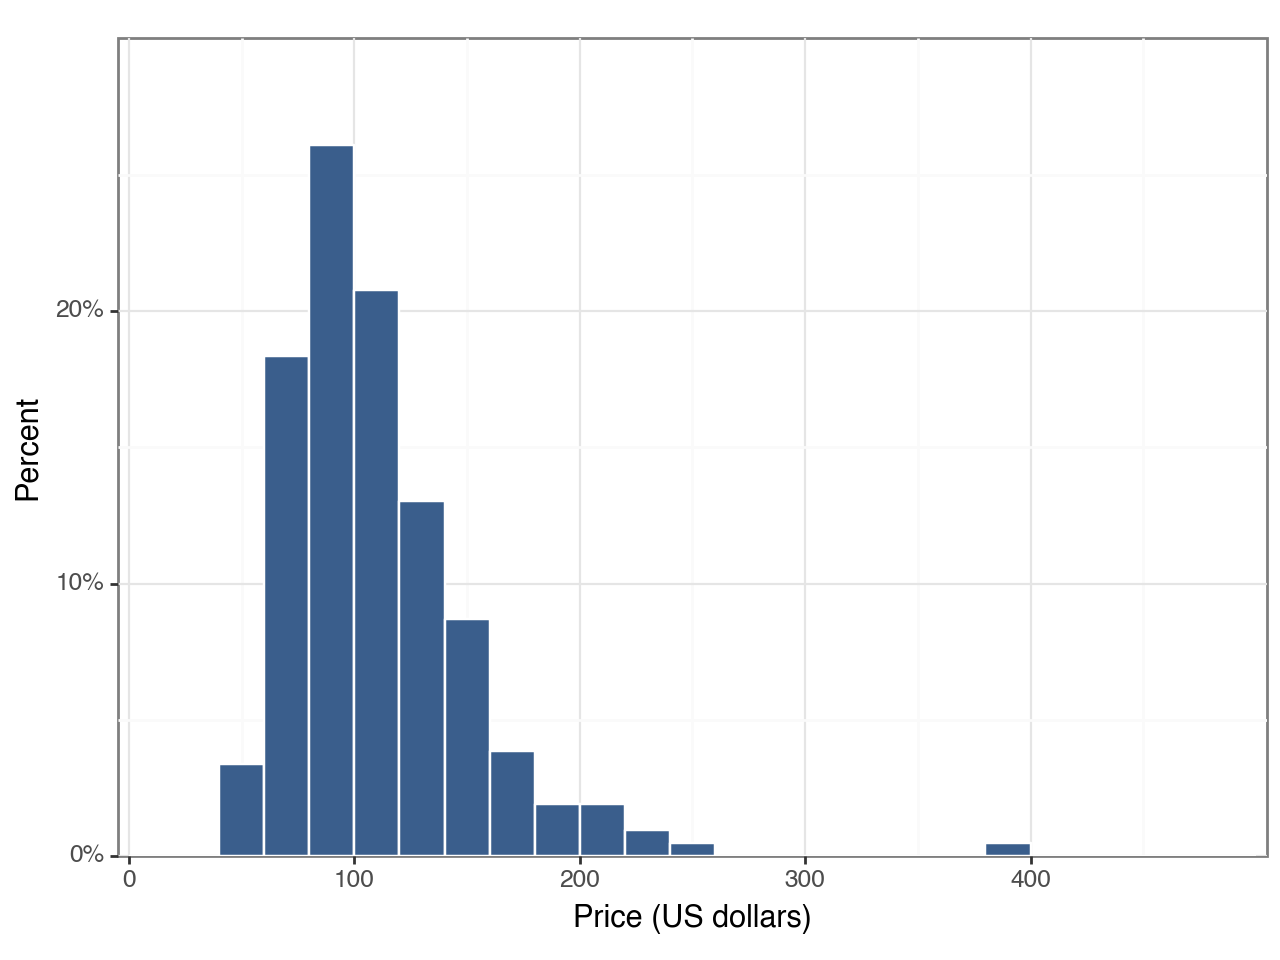

<Figure Size: (640 x 480)>

In [6]:
ggplot(hotels_europe_cut.query('city=="Vienna"'), aes(x="price")) + geom_histogram(
    aes(y="stat(count)/sum(stat(count))"),
    binwidth=20,
    fill=color[0],
    color="#FFFFFF",
    boundary=0,
    closed="left",
) + labs(x="Price (US dollars)", y="Percent") + scale_x_continuous(
    expand=(0.01, 0.01), limits=(0, 500), breaks=seq(0, 500, by=100)
) + scale_y_continuous(
    expand=(0.00, 0.00),
    limits=(0, 0.3),
    breaks=seq(0, 0.3, by=0.1),
    labels=percent_format(),
) + theme_bw()

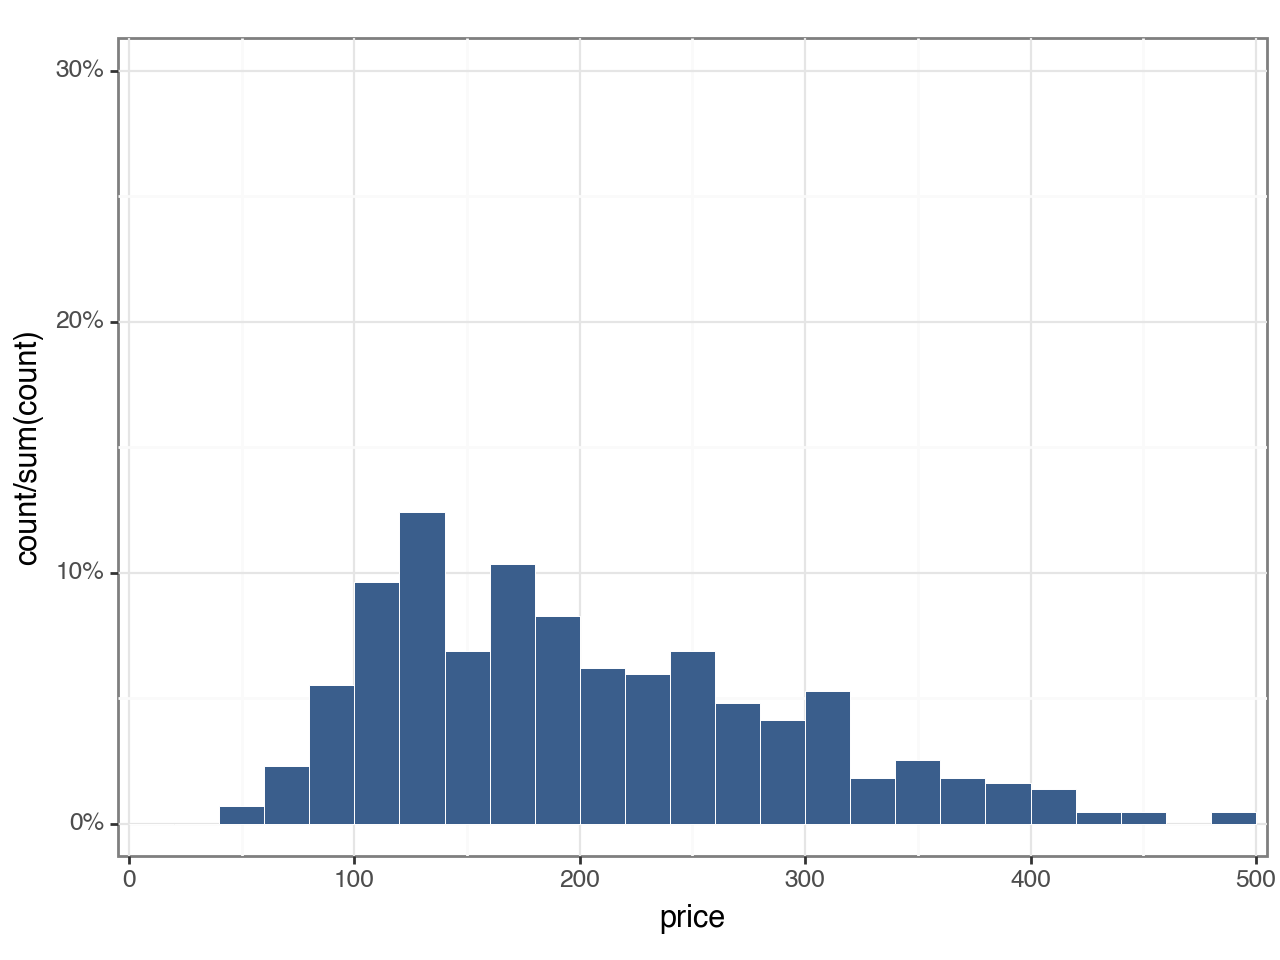

<Figure Size: (640 x 480)>

In [7]:
# London
ggplot(
    hotels_europe_cut.query('city=="London"'),
    aes(x="price", y="stat(count)/sum(stat(count))"),
) + geom_histogram(
    binwidth=20,
    fill=color[0],
    color="#FFFFFF",
    size=0.2,
    alpha=0.8,
    boundary=0,
    closed="left",
) + scale_y_continuous(
    labels=percent_format(), expand=[0.01, 0.01], limits=[0, 0.3]
) + scale_x_continuous(
    expand=[0.01, 0.01], limits=[0, 500], breaks=list(range(0, 600, 100))
) + theme_bw()

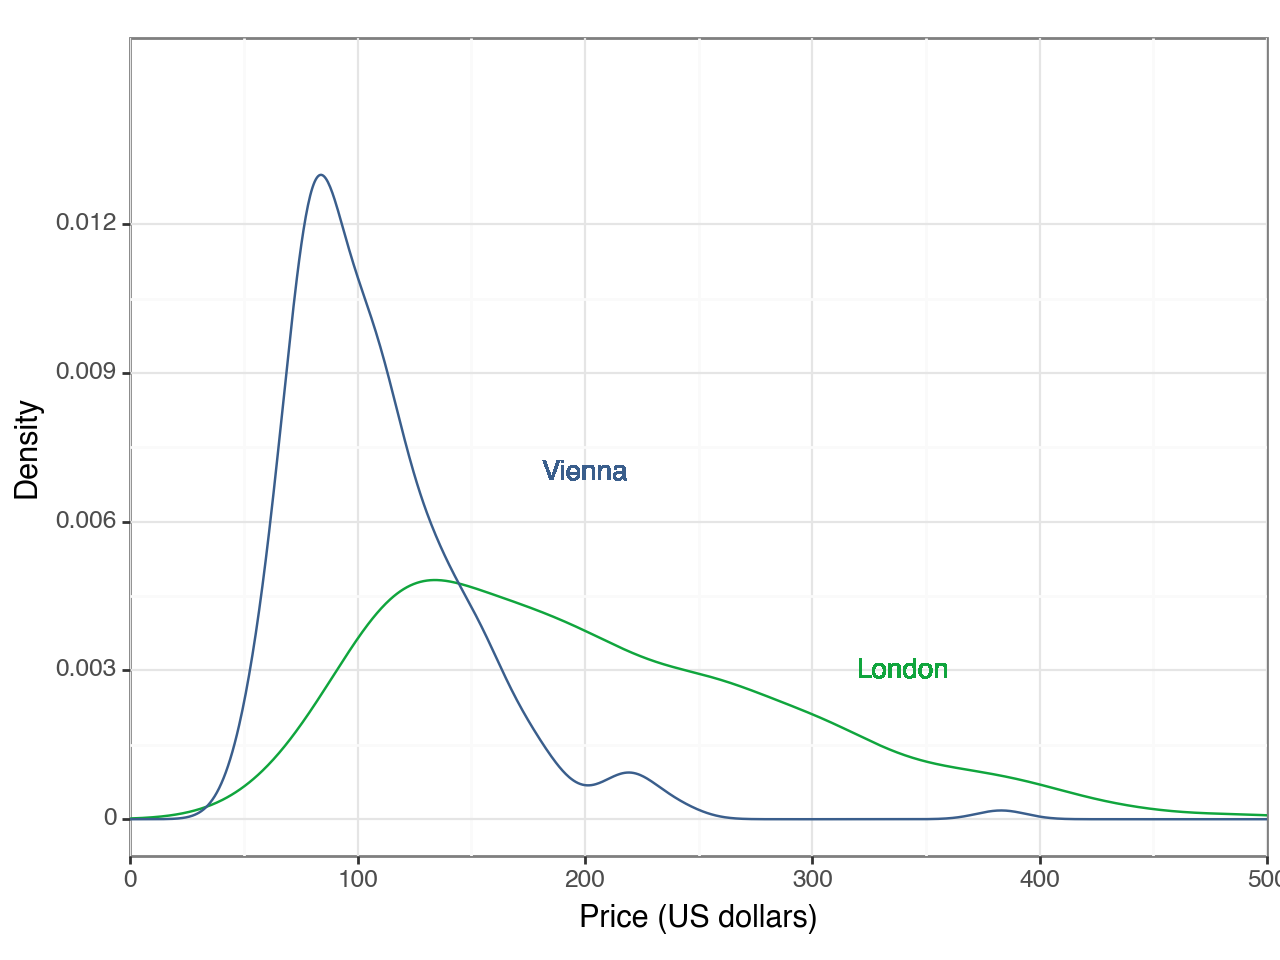

<Figure Size: (640 x 480)>

In [8]:
ggplot(hotels_europe_cut, aes(x="price", y="stat(density)", color="city")) + geom_line(
    stat="density",show_legend='False'
) + labs(x="Price (US dollars)", y="Density", color="") + scale_color_manual(
    name="", values=[color[1], color[0]], labels=["London", "Vienna"]
) + scale_y_continuous(
    limits=[0, 0.015], breaks=seq(0, 0.015, 0.003)
) + scale_x_continuous(
    expand=[0.0, 0.0], limits=[0, 500], breaks=seq(0, 501, 100)
) + geom_text(
    aes(x=340, y=0.003, label=["London"]), color=color[1], size=10
) + geom_text(
    aes(x=200, y=0.007, label=["Vienna"]), color=color[0], size=10
) + theme_bw()

### Now exploring Vienna hotels more in detail

In [28]:
vienna["accommodation_type"].value_counts() 

accommodation_type
Hotel                  264
Apartment              124
Pension                 16
Guest House              8
Hostel                   6
Bed and breakfast        4
Apart-hotel              4
Vacation home Condo      2
Name: count, dtype: int64

In [2]:
# Now exploring the Vienna dataset more in detail

In [29]:
vienna_cut=vienna.loc[lambda x: x['accommodation_type']=="Hotel"] 
# not clear what this is doing? Generative AI can help!

### Histograms

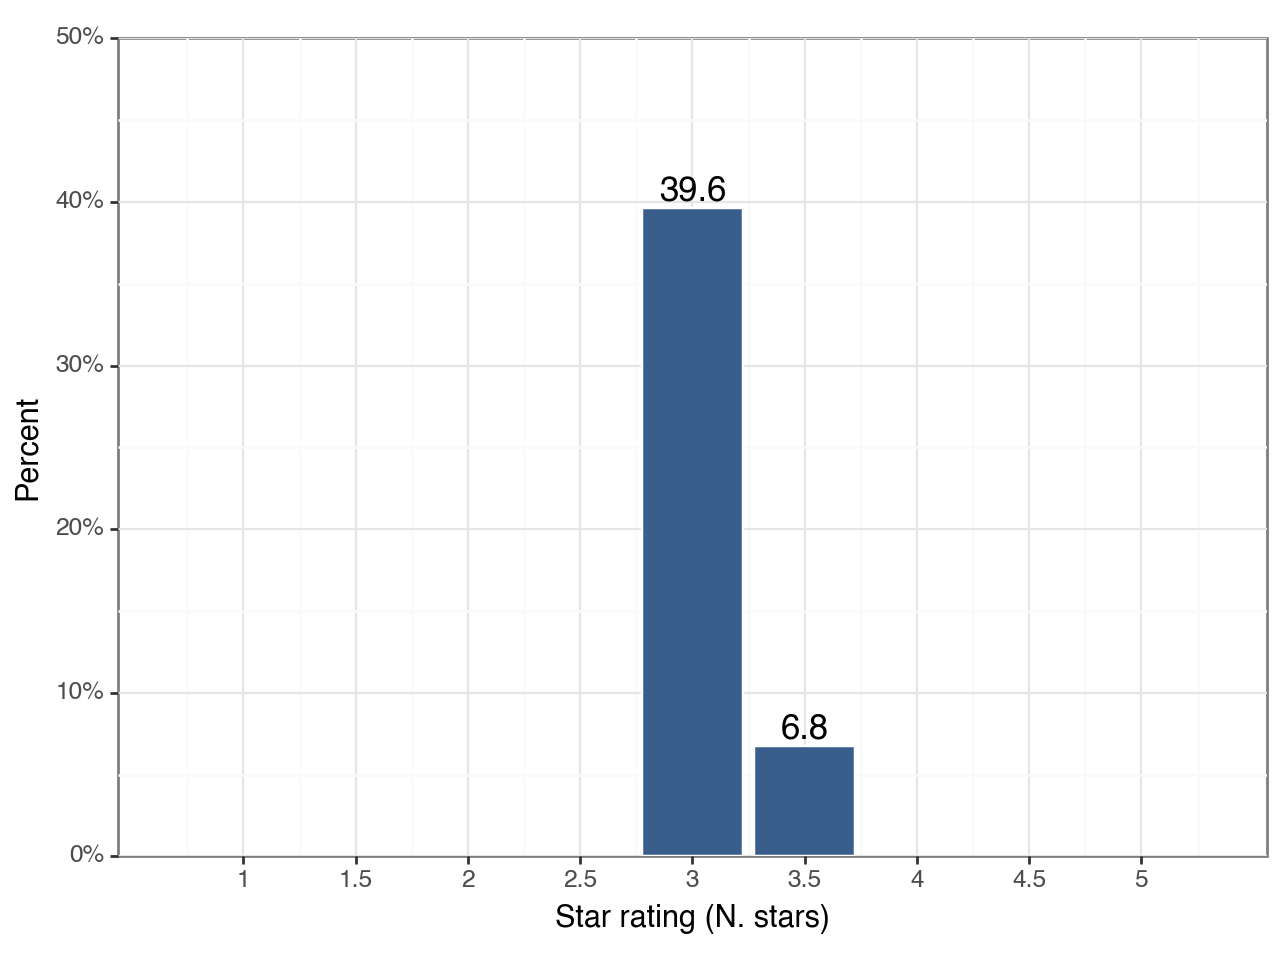

<Figure Size: (640 x 480)>

In [49]:
ggplot(vienna_cut, aes(x="stars", y="stat(count)/sum(stat(count))")) + geom_bar(
    color="white", fill=color[0], alpha=0.8
) + labs(x="Star rating (N. stars)", y="Percent") + expand_limits(
    x=0.01, y=0.01
) + scale_x_continuous(
    expand=[0.01, 0.01], limits=[0.5, 5.5], breaks=seq(1, 5.1, 0.5)
) + scale_y_continuous(
    expand=[0.00, 0.00],
    limits=[0, 0.5],
    breaks=seq(0, 0.51, 0.1),
    labels=percent_format(),
) + geom_text(
    aes(
        x="stars",
        y="[x+0.01 for x in stat(count)/sum(stat(count))]",
        label="[round(num,1) for num in stat(count)/sum(stat(count))*100)]",
    ),
    stat="count",
    size=12.5,
) + theme_bw()

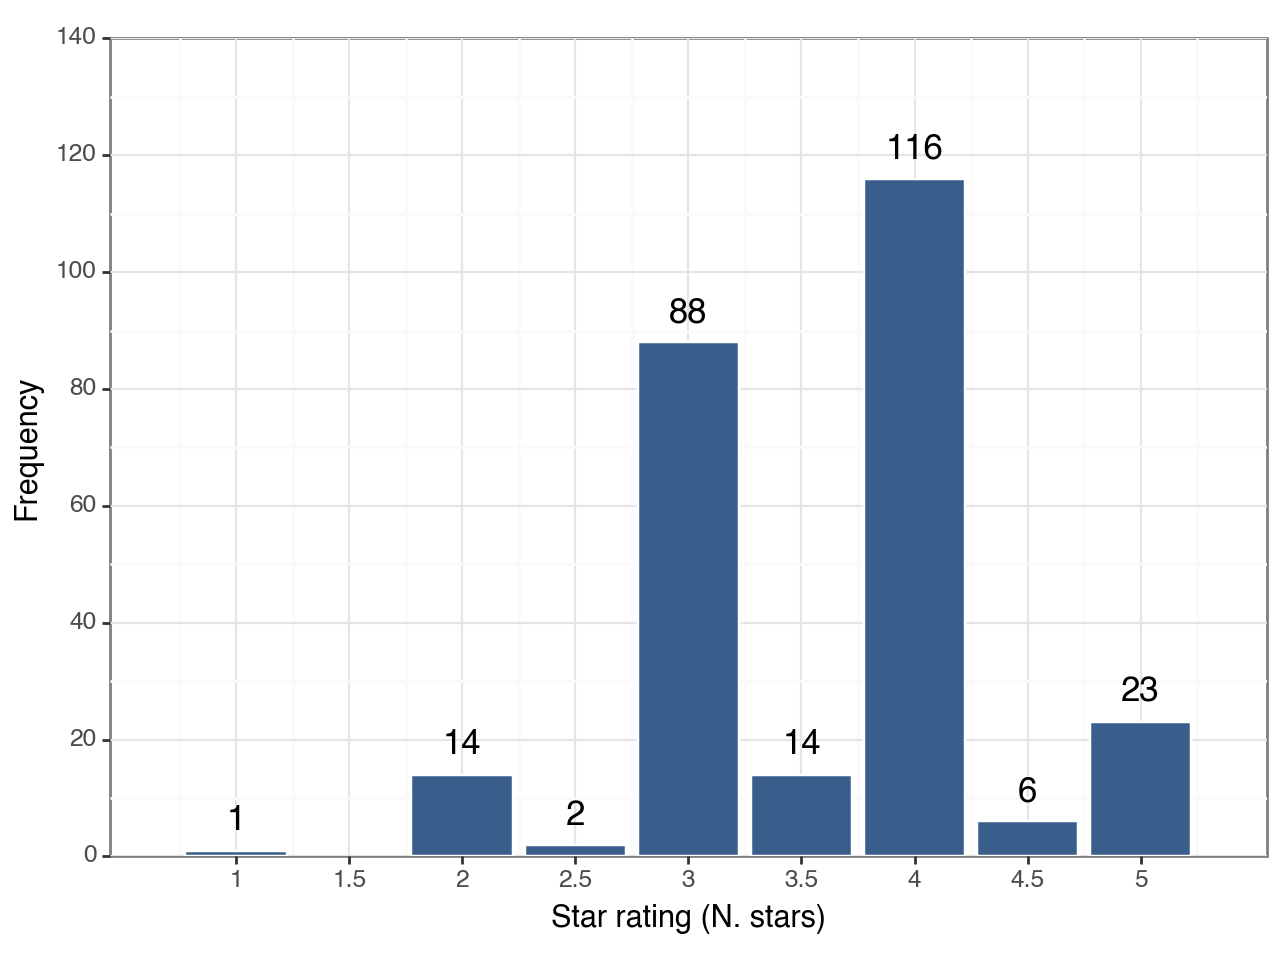

<Figure Size: (640 x 480)>

In [34]:
ggplot(vienna_cut, aes(x="stars",y="stat(count)")) + geom_bar(
    color="white", fill=color[0], alpha=0.8
) + labs(x="Star rating (N. stars)", y="Frequency") + expand_limits(
    x=0.01, y=0.01
) + scale_x_continuous(
    expand=[0.01, 0.01], limits=[0.5, 5.5], breaks=seq(1, 5.1, 0.5)
) + scale_y_continuous(
    expand=[0.00, 0.00],
    limits=[0, 140],
    breaks=seq(0, 141, 20)
) + geom_text(
    aes(
        x="stars",
        y="[x+5 for x in stat(count)]",
        label="stat(count)",
    ),
    stat="count",
    size=12.5,
) + theme_bw()

In [39]:
###############################################
### DISTRIBUTIONS
###############################################
# Apply filters:  3-4 stars, less than 8miles from center, without 1000 euro extreme value

vienna_cut = vienna.loc[
    (vienna["accommodation_type"] == "Hotel")
    & (vienna["city_actual"] == "Vienna")
    & (vienna["stars"] >= 3)
    & (vienna["stars"] <= 4)
    & (~vienna["stars"].isnull())
    & (vienna["price"] <= 600)
]

In [40]:
vienna_cut['city'].value_counts()

city
Vienna    207
Name: count, dtype: int64

In [41]:
vienna_cut['stars'].value_counts()

stars
4.0    111
3.0     82
3.5     14
Name: count, dtype: int64

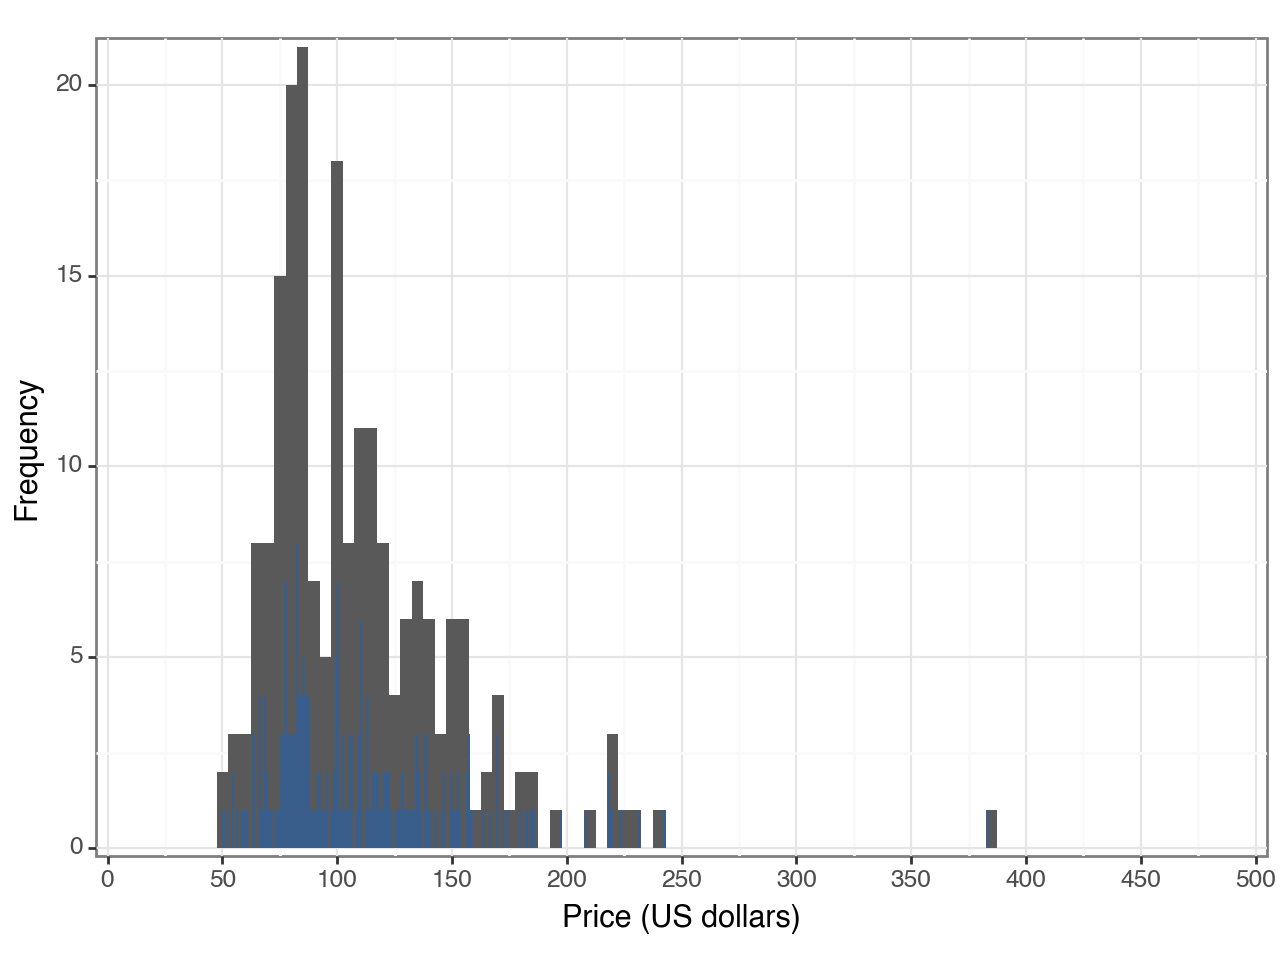

<Figure Size: (640 x 480)>

In [46]:
####################################################################################
# Figure 3.2 a) and b)
####################################################################################

ggplot(vienna_cut, aes(x="price")) + geom_histogram(
    y="stat(count)/sum(stat(count))", binwidth=5, size=0.5
) + geom_histogram(
    binwidth=1, fill=color[0], size=0.5, alpha=0.8, boundary=0,closed="left"
) + labs(
    x="Price (US dollars)", y="Frequency"
) + expand_limits(
    x=0.01, y=0.01
) + scale_x_continuous(
    expand=[0.01, 0.01], limits=[0, 500], breaks=seq(0, 501, 50)
) + scale_y_continuous(
    expand=[0.01, 0.01]
) + theme_bw()

In [ ]:
ggplot(vienna_cut, aes(x="price")) + geom_histogram(
    y="stat(count)/sum(stat(count))", binwidth=10, fill=color[0],color="white",boundary=0,closed="left"
) + labs(x="Price (US dollars)", y="Frequency") + expand_limits(
    x=0.01, y=0.01
) + scale_x_continuous(
    expand=[0.01, 0.01], limits=[0, 500], breaks=seq(0, 501, 50)
) + scale_y_continuous(
    expand=[0.01, 0.01], limits=[0, 45], breaks=seq(0, 46, 5)
) + theme_bw()

In [ ]:
####################################################################################
# Figure 3 a,b
####################################################################################
ggplot(vienna_cut, aes(x="price")) + geom_histogram(
    y="stat(count)/sum(stat(count))", binwidth=40, fill=color[0], color="white", boundary=0,closed="left"
) + labs(x="Price (US dollars)", y="Frequency") + scale_x_continuous(
    expand=[0.0, 0.0], limits=[0, 510], breaks=seq(0, 501, 80)
) + scale_y_continuous(
    expand=[0.0, 0.0], limits=[0, 120], breaks=seq(0, 121, 20)
) + theme_bw()

In [ ]:
ggplot(vienna_cut, aes(x="price")) + geom_histogram(
    y="stat(count)/sum(stat(count))", binwidth=80, fill=color[0],color="white",boundary=0,closed="left"
) + labs(x="Price (US dollars)", y="Frequency") + scale_x_continuous(
    expand=[0.0, 0.0], limits=[0, 510], breaks=seq(0, 501, 80)
) + scale_y_continuous(
    expand=[0.0, 0.0], limits=[0, 160], breaks=seq(0, 151, 50)
) + theme_bw()

In [ ]:
###############################################
  ### EXTREME VALUES
###############################################
# Apply filters: 3-4 stars, less than 8miles from center, without 1000 euro extreme value

vienna_cut = vienna.loc[
    (vienna["accommodation_type"] == "Hotel")
    & (vienna["stars"] >= 3)
    & (vienna["stars"] <= 4)
    & (~vienna["stars"].isnull())
    & (vienna["price"] <= 1000)
]

In [ ]:
########################x
# Figure 3.4
ggplot(vienna_cut, aes(x="distance")) + geom_histogram(
    y="stat(count)/sum(stat(count))", binwidth=0.5, fill=color[0],color="white",boundary=0,closed="left"
) + labs(x="Distance to city center (miles)", y="Frequency") + scale_x_continuous(
    expand=[0.0, 0.0], limits=[0, 14], breaks=seq(0, 15, 2)
) + scale_y_continuous(
    expand=[0.0, 0.0], limits=[0, 61], breaks=seq(0, 61, 10)
) + theme_bw()

In [ ]:
# with annotation
ggplot(vienna_cut, aes(x="distance")) + geom_histogram(
    y="stat(count)/sum(stat(count))",
    binwidth=0.5,
    fill=color[0],
    color="white",
    boundary=0,
    closed="left",
) + labs(x="Distance to city center (miles)", y="Frequency") + scale_x_continuous(
    expand=[0.0, 0.0], limits=[0, 14], breaks=seq(0, 15, 2)
) + scale_y_continuous(
    expand=[0.0, 0.0], limits=[0, 61], breaks=seq(0, 61, 10)
) + geom_segment(
    aes(x=8.2, y=0, xend=8.2, yend=60), color=color[1], size=1
) + annotate(
    "text", x=11, y=29, label="Too far out", size=10
) + annotate(
    geom="rect", xmin=8.2, xmax=14, ymin=0, ymax=60, alpha=0.1, fill = "yellow"
) + theme_bw()

In [ ]:
# look at actual city
vienna_cut['city_actual'].value_counts()

In [ ]:
####################################################################################
# Figure price with extreme
# Apply filters:  3-4 stars, less than 8miles from center, without 1000 euro extreme value
vienna_cut = vienna.loc[
    (vienna["accommodation_type"] == "Hotel")
    & (vienna["stars"] >= 3)
    & (vienna["stars"] <= 4)
    & (~vienna["stars"].isnull())
]

In [ ]:
ggplot(vienna_cut, aes(x="price")) + geom_histogram(
    y="stat(count)/sum(stat(count))", binwidth=20, fill=color[0], color="white",boundary=0,closed="left"
) + labs(x="Price (US dollars)", y="Frequency") + scale_x_continuous(
    expand=[0.00, 0.00], limits=[0, 1100], breaks=seq(0, 1101, 100)
) + expand_limits(
    x=0.00, y=0.00
) + theme_bw()

### Scatter plots

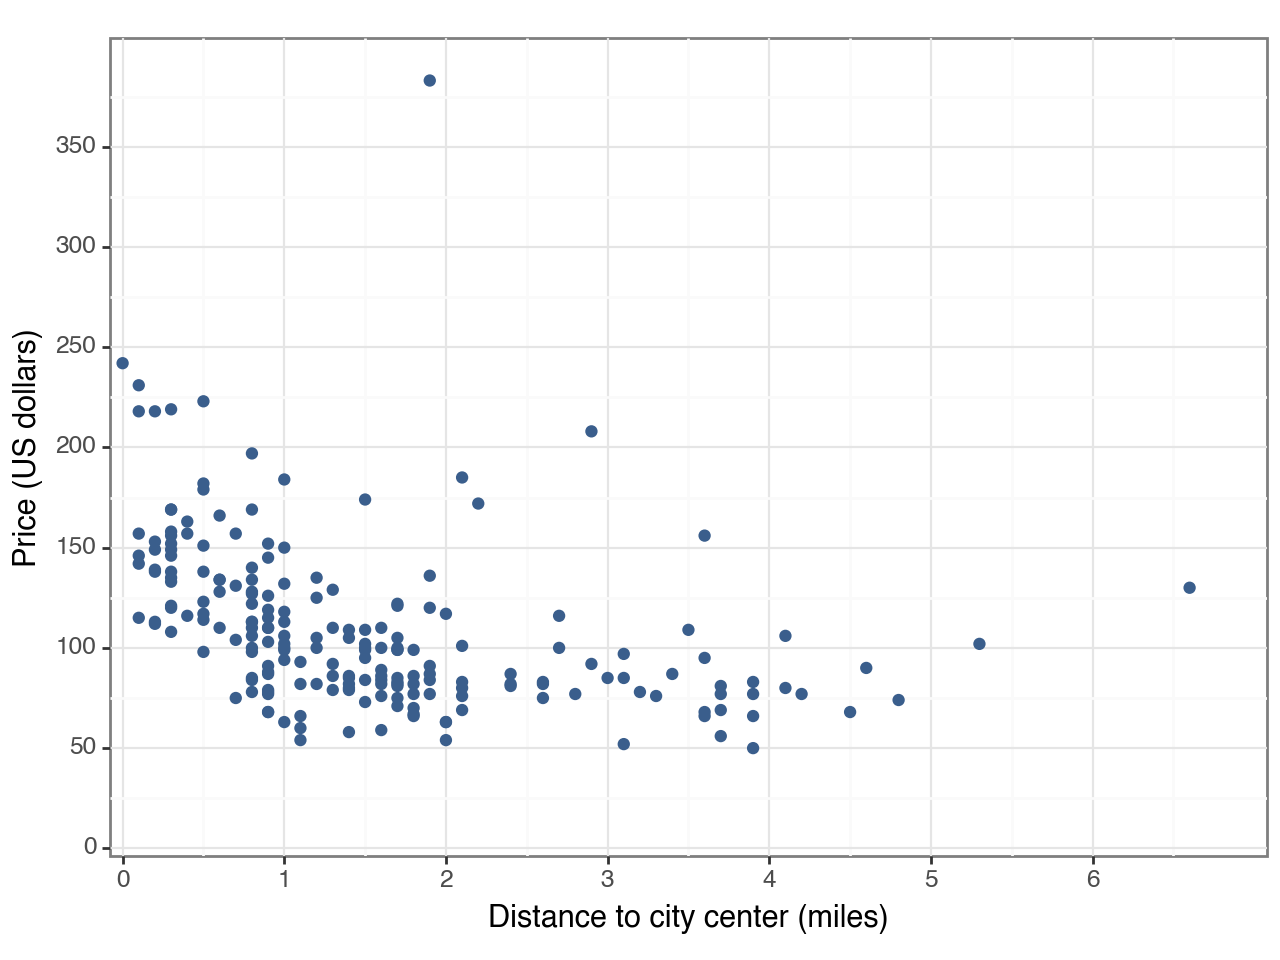

In [47]:
p1 = (
    ggplot(vienna_cut, aes(x="distance", y="price"))
    + geom_point(color=color[0])
    + expand_limits(x=0.01, y=0.01)
    + scale_x_continuous(expand=[0.01, 0.01], limits=[0, 7], breaks=seq(0, 7, 1))
    + scale_y_continuous(expand=[0.01, 0.01], limits=[0, 400], breaks=seq(0, 400, 50))
    + labs(x="Distance to city center (miles)", y="Price (US dollars)")
    + theme_bw()
)
print(p1)

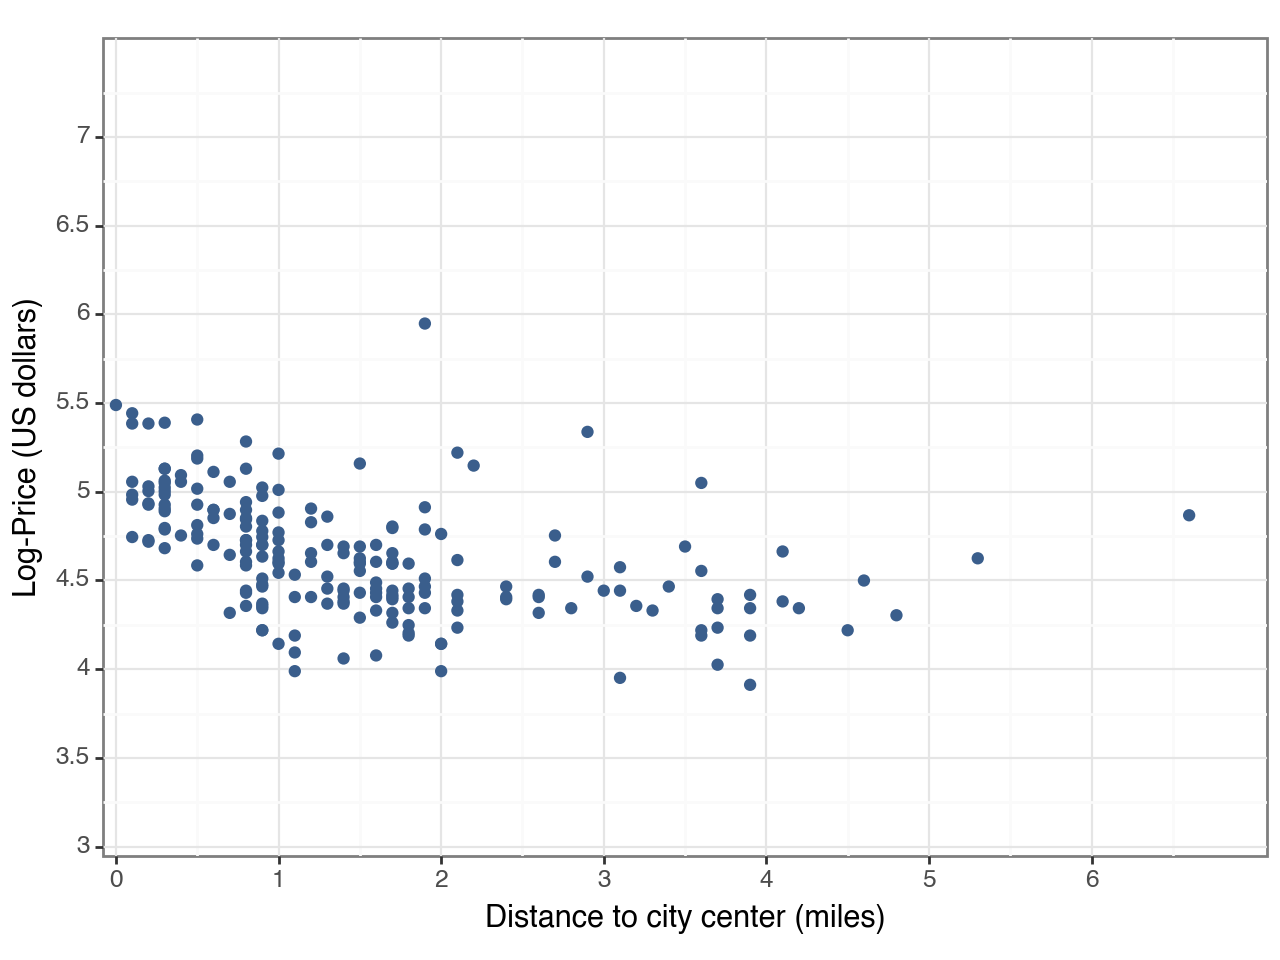

In [48]:
vienna_cut["logprice"] = np.log(vienna_cut["price"])
p1 = (
    ggplot(vienna_cut, aes(x="distance", y="logprice"))
    + geom_point(color=color[0])
    + expand_limits(x=0.01, y=0.01)
    + scale_x_continuous(expand=[0.01, 0.01], limits=[0, 7], breaks=seq(0, 7, 1))
    + scale_y_continuous(expand=[0.01, 0.01], limits=[3, 7.5], breaks=seq(3, 7.5, 0.5))
    + labs(x="Distance to city center (miles)", y="Log-Price (US dollars)")
    + theme_bw()
)
print(p1)

In [ ]:
vienna_cut["logdistance"] = np.log(vienna_cut["distance"]+1)
p1 = (
    ggplot(vienna_cut, aes(x="logdistance", y="price"))
    + geom_point(color=color[0])
    + expand_limits(x=0.01, y=0.01)
    + scale_x_continuous(expand=[0.01, 0.01], limits=[0, 3], breaks=seq(0, 3, 0.5))
    + scale_y_continuous(expand=[0.01, 0.01], limits=[0, 400], breaks=seq(0, 400, 50))
    + labs(x="Distance to city center (miles)", y="Log-Price (US dollars)")
    + theme_bw()
)
print(p1)